# Análise independente: Netflix

Estado: a fazer. Leia o README desta pasta. Este caderno contém somente a estrutura da tentativa; não há resultados gerados. Execute com esta pasta como diretório de trabalho.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
base = pd.read_csv("netflix_titles.csv")
base.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


## Perguntas e expectativas

Primeiro preciso entender o dataset
- qual a distribuição dos titulos tipo (type) e ano de lançamento (release_year)
- Qual a distribuição dos paises
- Qual a duração media dos titulos, Separar series, filmes, e depois ver os dois juntos.
- Qual a distribuição dos titulos por seu "ranting" que é a classificação indicativa dos titulos

In [4]:
base.shape

(8807, 12)

### Primeiro analise da coluna "release_year"

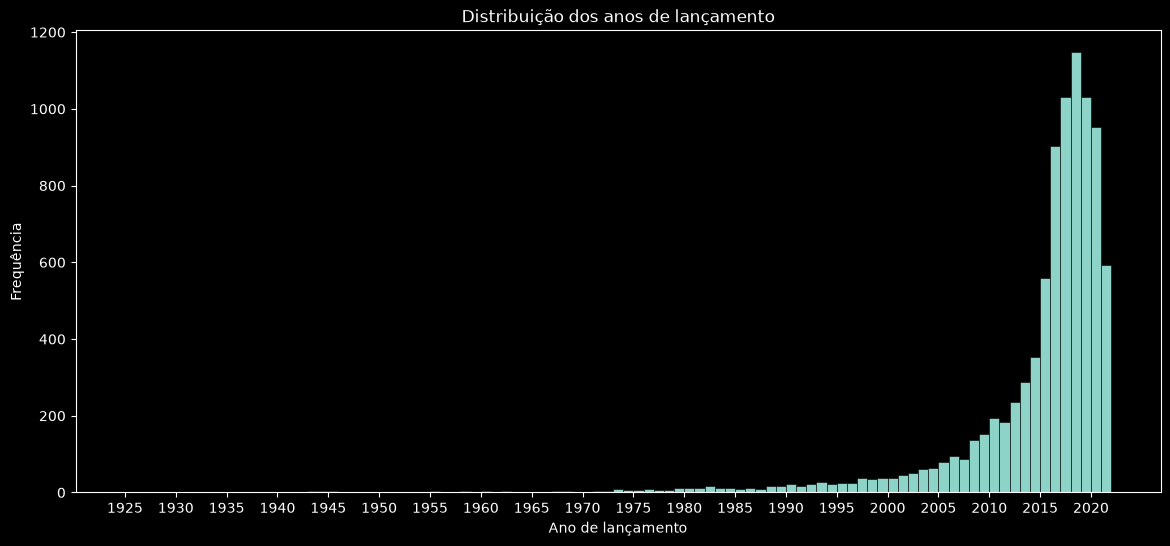

In [5]:
release_year = base['release_year']

plt.figure(figsize=(14,6))

plt.hist(
    release_year,
    bins=range(release_year.min(), release_year.max() + 2),
    edgecolor="black",
    linewidth=0.4
)

plt.xlabel("Ano de lançamento")
plt.ylabel("Frequência")
plt.title("Distribuição dos anos de lançamento")

plt.xticks(range(release_year.min(), release_year.max() + 1, 5))
plt.show()

O histograma mostra que a maior parte dos filmes foram lançados entre 2015 a 2021. Contendo alguns outliers, que ao primeiro parecer, aparantam ser dados fora do padrão, mas não necessariamente erros. 

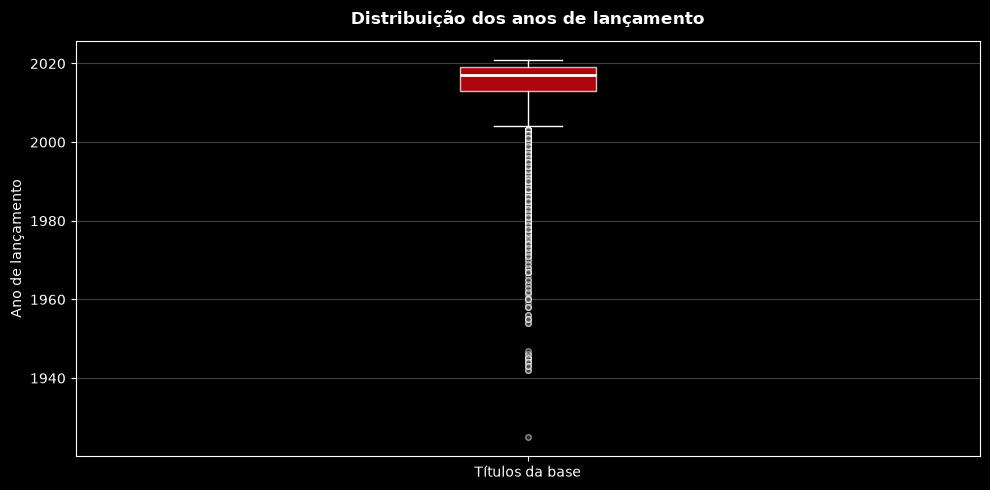

In [24]:
plt.figure(figsize=(10, 5))
plt.boxplot(
    base["release_year"],
    patch_artist=True,
    boxprops=dict(facecolor="#E50914", alpha=0.75),
    medianprops=dict(color="white", linewidth=2),
    flierprops=dict(marker="o", markerfacecolor="#555555", markersize=4, alpha=0.5)
)
plt.title("Distribuição dos anos de lançamento", pad=12, weight="bold")
plt.ylabel("Ano de lançamento")
plt.xticks([1], ["Títulos da base"])
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

Com essa detecção inicial de possiveis oultliers na coluna release_year, seguindo a metrica IQR usada no boxplot acima definirei o limite superior e inferior para com isso delimitar quais são os outliers e checalos criando um filtro.

Mas porque IQR? IQR usa quartis, que são pouco afetados a valores extremos. A distribuição uma fote concentração central com uma cauda longa a esquerda aumentando valores sensiveis como media, desvio padrão,

In [32]:
q1 = base["release_year"].quantile(0.25)
q3 = base["release_year"].quantile(0.75)
IQR = q3 - q1

limite_inferior = q1 - 1.5 * IQR
limite_superior = q3 + 1.5 * IQR

print(f"Limite inferior: {limite_inferior}")
print(f"Limite superior: {limite_superior}")

outliers_release_year = base.loc[
    (base["release_year"] < limite_inferior)
    | (base["release_year"] > limite_superior)
].sort_values("release_year")

outliers_release_year[["title", "type", "release_year", "country", "listed_in"]]

Limite inferior: 2004.0
Limite superior: 2028.0


,title,type,release_year,country,listed_in
4250,Pioneers: First Women Filmmakers*,TV Show,1925,NaN,TV Shows
7790,Prelude to War,Movie,1942,United States,"Classic Movies, Documentaries"
8205,The Battle of Midway,Movie,1942,United States,"Classic Movies, Documentaries"
8763,WWII: Report from the Aleutians,Movie,1943,United States,Documentaries
8739,Why We Fight: The Battle of Russia,Movie,1943,United States,Documentaries
...,...,...,...,...,...
201,Kucch To Hai,Movie,2003,India,"Dramas, International Movies, Thrillers"
163,My Boss's Daughter,Movie,2003,United States,"Comedies, Romantic Movies"
172,School of Rock,Movie,2003,"United States, Germany","Comedies, Music & Musicals"
174,Tears of the Sun,Movie,2003,United States,"Action & Adventure, Dramas"


In [43]:
base["release_year"].agg([
    "mean",
    "median",
    "std",
    "min",
    "max"
])


mean      2014.180198
median    2017.000000
std          8.819312
min       1925.000000
max       2021.000000
Name: release_year, dtype: float64

In [47]:
print(f"Q1 = {q1}, Q3 = {q3}, IQR = {IQR}")

Q1 = 2013.0, Q3 = 2019.0, IQR = 6.0


In [ ]:
base["release_year"].skew()

np.float64(-3.4465650403316013)

In [35]:
IQR

np.float64(6.0)

In [37]:
base["release_year"].median()

np.float64(2017.0)

In [ ]:
base["release_year"].mean()

np.float64(2014.1801975701146)

In [36]:
base["release_year"].std()

np.float64(8.819312130833966)

## Dados e limitações

Local da base: `netflix_titles.csv`. Carregue o arquivo, examine o que cada linha representa e registre fonte/período conhecido, tipos e problemas. Não presuma que o arquivo seja atual.

## Qualidade e decisões

Registre problema, quantidade afetada, tratamento escolhido e justificativa. Confira o efeito de cada alteração.

## Análise das perguntas

Implemente suas consultas e gráficos. Explique denominadores, filtros e resultados. Acrescente células conforme necessário.

## Conclusões

Responda às perguntas em frases claras. Separe observação, interpretação e limitação. Termine com um resumo de cinco frases.

## Verificação e próxima tentativa

- [ ] Conferi números e gráficos.
- [ ] Reiniciei o kernel e executei tudo.
- [ ] Expliquei uma limitação.
- [ ] Resolvi uma variação sem copiar a solução.

Dificuldade encontrada e próxima ação: _preencher_.